In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("All libraries imported successfully")

All libraries imported successfully


In [5]:
df = pd.read_csv('survey.csv')
print(df.shape)
df.head()

(1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [7]:
print(df.shape)
print(df.columns.tolist())

(1259, 27)
['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


In [9]:
print(df['treatment'].value_counts())

treatment
Yes    637
No     622
Name: count, dtype: int64


In [13]:
print(df.isnull().sum())

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64


In [21]:
#Fill missing values
df['work_interfere'] = df['work_interfere'].fillna(df['work_interfere'].mode()[0])
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Age                          0
Gender                       0
Country                      0
self_employed                0
family_history               0
treatment                    0
work_interfere               0
no_employees                 0
remote_work                  0
tech_company                 0
benefits                     0
care_options                 0
wellness_program             0
seek_help                    0
anonymity                    0
leave                        0
mental_health_consequence    0
phys_health_consequence      0
coworkers                    0
supervisor                   0
mental_health_interview      0
phys_health_interview        0
mental_vs_physical           0
obs_consequence              0
dtype: int64


In [23]:
print(df['Gender'].value_counts())


Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female                                              2
Female (trans)                                      2
Male-ish                                            1
Trans-female                                        1
Male (CIS)                                          1
Mal                  

In [25]:
def clean_gender(gender):
    gender = gender.lower().strip()
    if gender in['male', 'm', 'man', 'make', 'maile','msle', 'malr', 'mail', 'cis male', 'cis man', 'male (cis)', 'male-ish', 'male leaning androgynous', 'guy (-ish) ^_^']:
        return 'male'
    elif gender in ['female', 'f', 'woman', 'femake', 'femail', 'cis female', 'cis-female/femme', 'female (cis)', 'female (trans)', 'trans woman', 'trans-female']:
        return 'Female'
    else:
        return'Other'
df['Gender'] = df['Gender'].apply(clean_gender)
print(df['Gender'].value_counts())
        


Gender
male      992
Female    251
Other      16
Name: count, dtype: int64


In [29]:
print(df['Age'].describe())


count    1.259000e+03
mean     7.942815e+07
std      2.818299e+09
min     -1.726000e+03
25%      2.700000e+01
50%      3.100000e+01
75%      3.600000e+01
max      1.000000e+11
Name: Age, dtype: float64


In [31]:
print(df['Age'].sort_values().unique())
      

[      -1726         -29          -1           5           8          11
          18          19          20          21          22          23
          24          25          26          27          28          29
          30          31          32          33          34          35
          36          37          38          39          40          41
          42          43          44          45          46          47
          48          49          50          51          53          54
          55          56          57          58          60          61
          62          65          72         329 99999999999]


In [33]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]
print(df['Age'].describe())
print(f"Rows remaining: {df.shape[0]}")

count    1250.000000
mean       32.044800
std         7.203076
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        65.000000
Name: Age, dtype: float64
Rows remaining: 1250


In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#Encode target variable
df['treatment'] = le.fit_transform(df['treatment'])

df['treatment'].value_counts()

/var/folders/17/7kqgk57n6tq81_zyx96xxw6m0000gn/T/ipykernel_1794/2742344403.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['treatment'] = le.fit_transform(df['treatment'])


treatment
1    631
0    619
Name: count, dtype: int64

In [53]:
#Get all text columns ecept treatment
text_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Columns to encode:", text_columns)

#Encode all text columns
for col in text_columns:
    df[col] = le.fit_transform(df[col])

print("Done encoding")
print(df.head())


Columns to encode: []
Done encoding
   Age  Gender  Country  self_employed  family_history  treatment  \
0   37       0       44              0               0          1   
1   44       2       44              0               0          0   
2   32       2        6              0               0          0   
3   31       2       43              0               1          1   
4   31       2       44              0               0          0   

   work_interfere  no_employees  remote_work  tech_company  ...  anonymity  \
0               1             4            0             1  ...          2   
1               2             5            0             0  ...          0   
2               2             4            0             1  ...          0   
3               1             2            0             1  ...          1   
4               0             1            1             1  ...          0   

   leave  mental_health_consequence  phys_health_consequence  coworkers  \
0    

In [61]:
#Separate features and target
X = df.drop('treatment', axis=1)
y = df['treatment']

#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")



Training set size: (1000, 23)
Testing set size: (250, 23)


In [67]:
from sklearn.ensemble import RandomForestClassifier

#Build and train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [71]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.75

Detailed Report:
              precision    recall  f1-score   support

           0       0.69      0.81      0.75       115
           1       0.81      0.70      0.75       135

    accuracy                           0.75       250
   macro avg       0.75      0.75      0.75       250
weighted avg       0.76      0.75      0.75       250



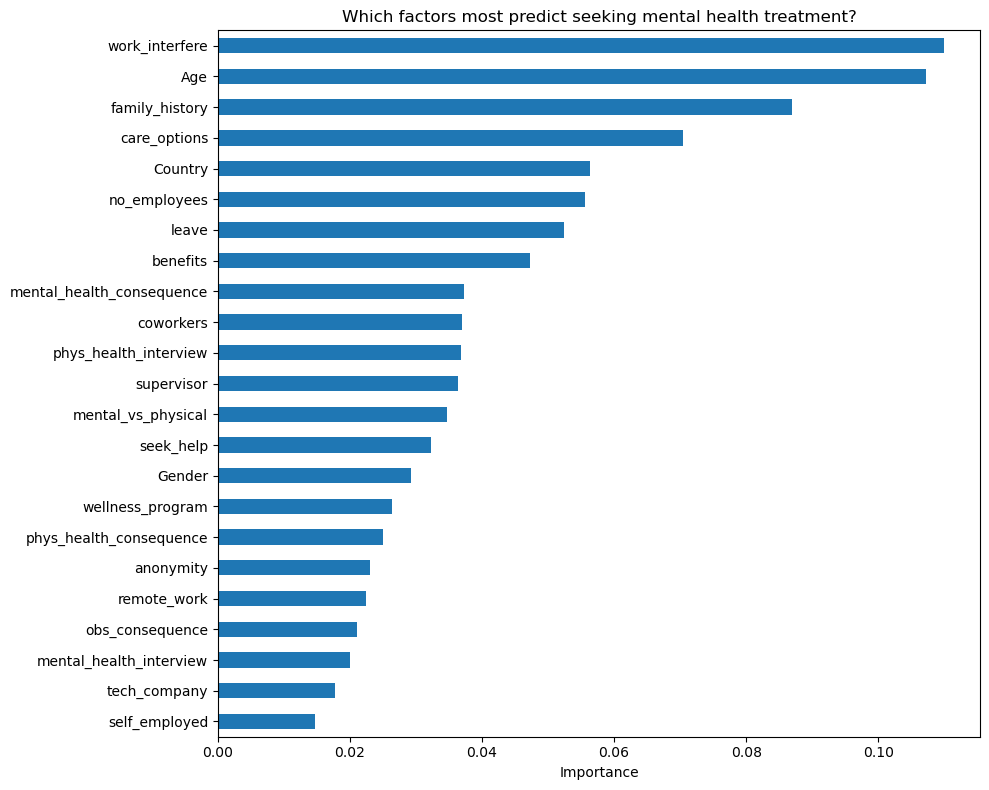

In [79]:
import pandas as pd 
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(10,8))
plt.title('Which factors most predict seeking mental health treatment?')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [83]:
def extract(filepath):
    """Extract: Load raw data from source"""
    df = pd.read_csv(filepath)
    print(f"Extracted {df.shape[0]} rows and {df.shape[1]} columns")
    return df

def transform(df):
    """Transform: Clean and prepare data"""
    #Drop unnecessary columns
    df = df.drop(['Timestamp', 'comments', 'state'], axis=1, errors='ignore')
    
    # Clean Age
    df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]
    
    # Clean Gender
    def clean_gender(gender):
        gender = gender.lower().strip()
        if gender in ['male', 'm', 'man', 'make', 'mal', 'maile', 'msle', 'malr', 'mail', 'cis male', 'cis man', 'male (cis)', 'male-ish', 'male leaning androgynous', 'guy (-ish) ^_^']:
            return 'Male'
        elif gender in ['female', 'f', 'woman', 'femake', 'femail', 'cis female', 'cis-female/femme', 'female (cis)', 'female (trans)', 'trans woman', 'trans-female']:
            return 'Female'
        else:
            return 'Other'
    
    df['Gender'] = df['Gender'].apply(clean_gender)
    
    # Fill missing values
    df['work_interfere'] = df['work_interfere'].fillna(df['work_interfere'].mode()[0])
    df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])
    
    print(f"Transformed data: {df.shape[0]} rows remaining")
    return df
def load(df, db_path):
    """Load: Save cleaned data to SQLite database"""
    import sqlite3
    conn = sqlite3.connect(db_path)
    df.to_sql('mental_health', conn, if_exists='replace', index=False)
    conn.close()
    print(f"Loaded data into {db_path}")
#Run the ETL pipeline
raw_df = extract('survey.csv')
cleaned_df = transform(raw_df)
load(cleaned_df, 'mental_health.db')

Extracted 1259 rows and 27 columns
Transformed data: 1250 rows remaining
Loaded data into mental_health.db


In [85]:
import sqlite3

conn = sqlite3.connect('mental_health.db')
query_result = pd.read_sql_query("SELECT COUNT(*) as total_records FROM mental_health", conn)
print(query_result)

# Also run a meaningful query
query2 = pd.read_sql_query("""
    SELECT treatment, COUNT(*) as count 
    FROM mental_health 
    GROUP BY treatment
""", conn)
print(query2)
conn.close()

   total_records
0           1250
  treatment  count
0        No    619
1       Yes    631


In [89]:
def predict_treatment(age, gender, family_history, work_interfere):
    # Use a real test row as base
    sample = X_test.iloc[0].copy()
    
    # Override the key values
    sample['Age'] = age
    sample['Gender'] = gender
    sample['family_history'] = family_history
    sample['work_interfere'] = work_interfere
    
    # Reshape for prediction
    input_data = pd.DataFrame([sample])
    
    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)
    
    result = "Likely to seek treatment" if prediction[0] == 1 else "Unlikely to seek treatment"
    confidence = max(probability[0]) * 100
    
    print(f"Prediction: {result}")
    print(f"Confidence: {confidence:.1f}%")

# Test it
predict_treatment(age=28, gender=1, family_history=1, work_interfere=2)

Prediction: Likely to seek treatment
Confidence: 58.0%
